In [50]:
#Importing The Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

import seaborn as sns

#Loading the Dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#Data Cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [51]:
df_US = df[df['job_country'] == 'United States']

In [52]:
df_skills = df_US.explode('job_skills')

In [53]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count

job_skills  job_title_short          
airflow     Business Analyst               38
            Cloud Engineer                 27
            Data Analyst                  387
            Data Engineer                4716
            Data Scientist               1166
                                         ... 
zoom        Machine Learning Engineer       5
            Senior Data Analyst            50
            Senior Data Engineer           30
            Senior Data Scientist          25
            Software Engineer              16
Length: 1870, dtype: int64

In [54]:
df_skills_count = df_skills_count.reset_index(name= 'skill_count')

In [55]:
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [56]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

Data Analyst rows: 218
Data Engineer rows: 222
Data Scientist rows: 227


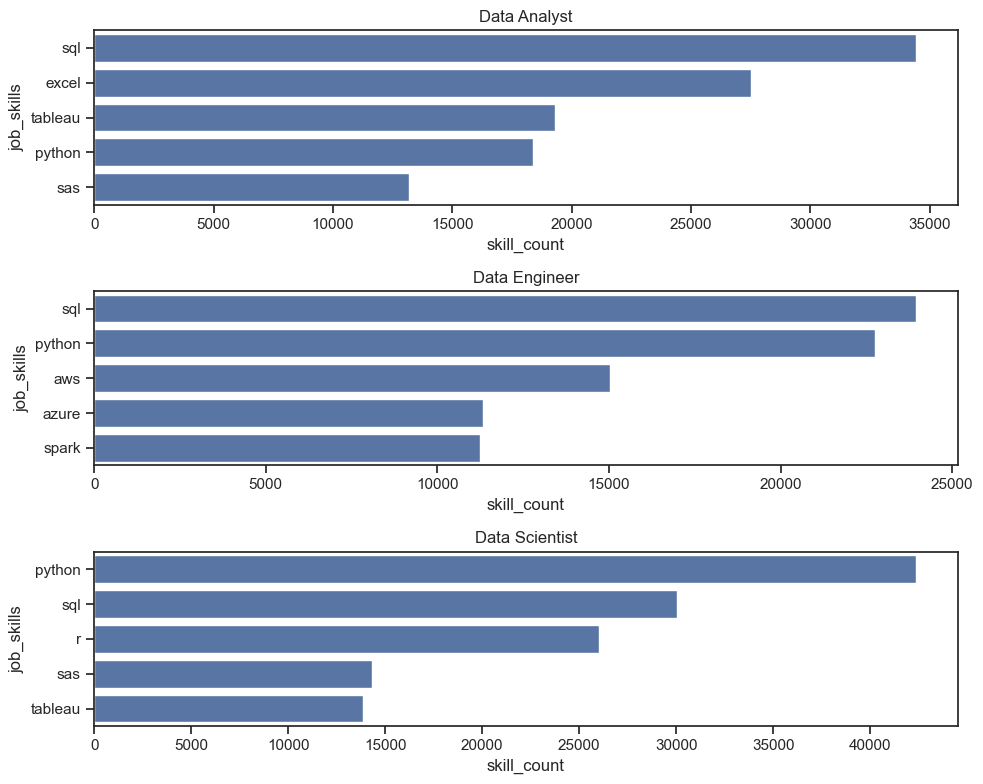

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_skills_count['job_title_short'] = df_skills_count['job_title_short'].str.lower().str.strip()

fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 8))

if len(job_titles) == 1:
    ax = [ax]

for i, job_title in enumerate(job_titles):
    
    # MATCH using lowercase
    df_plot = df_skills_count[
        df_skills_count['job_title_short'] == job_title.lower()
    ]

    print(f"{job_title} rows:", len(df_plot))  

    if df_plot.empty:
        continue  # skip empty plots

    df_plot = df_plot.head(5)[::-1]

    sns.barplot(
        data=df_plot,
        x='skill_count',
        y='job_skills',
        ax=ax[i]
    )

    ax[i].set_title(job_title)
    ax[i].invert_yaxis()

plt.tight_layout()
plt.show()

In [58]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total').dropna()

In [59]:
import pandas as pd

# -------------------------------
# STEP 1: Clean both dataframes
# -------------------------------

# Normalize text (VERY IMPORTANT for merge)
df_skills_count['job_title_short'] = (
    df_skills_count['job_title_short']
    .str.lower()
    .str.strip()
)

df_job_title_count['job_title_short'] = (
    df_job_title_count['job_title_short']
    .str.lower()
    .str.strip()
)

# -------------------------------
# STEP 2: Merge datasets
# -------------------------------

df_skills_perc = pd.merge(
    df_skills_count,
    df_job_title_count,
    on='job_title_short',
    how='inner'   # avoids NaN
)

# -------------------------------
# STEP 3: Calculate percentage
# -------------------------------

df_skills_perc['skill_percent'] = (
    df_skills_perc['skill_count'] / df_skills_perc['jobs_total']
) * 100

# -------------------------------
# STEP 4: Clean final output
# -------------------------------

# Optional: sort for better readability
df_skills_perc = df_skills_perc.sort_values(
    by=['job_title_short', 'skill_percent'],
    ascending=[True, False]
)

# Reset index (clean view)
df_skills_perc = df_skills_perc.reset_index(drop=True)

# -------------------------------
# OUTPUT
# -------------------------------

df_skills_perc.head(10)

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,business analyst,3564,7382,48.279599
1,excel,business analyst,3128,7382,42.373341
2,tableau,business analyst,2213,7382,29.978326
3,power bi,business analyst,1558,7382,21.105391
4,python,business analyst,1409,7382,19.086968
5,sas,business analyst,1074,7382,14.548903
6,powerpoint,business analyst,1042,7382,14.115416
7,r,business analyst,929,7382,12.584665
8,word,business analyst,890,7382,12.056353
9,oracle,business analyst,496,7382,6.719046


Data Analyst rows: 218
Data Engineer rows: 222
Data Scientist rows: 227


/var/folders/qz/809bk0757sz958kkr3n0_v9h0000gn/T/ipykernel_28468/1706183869.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/qz/809bk0757sz958kkr3n0_v9h0000gn/T/ipykernel_28468/1706183869.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/qz/809bk0757sz958kkr3n0_v9h0000gn/T/ipykernel_28468/1706183869.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


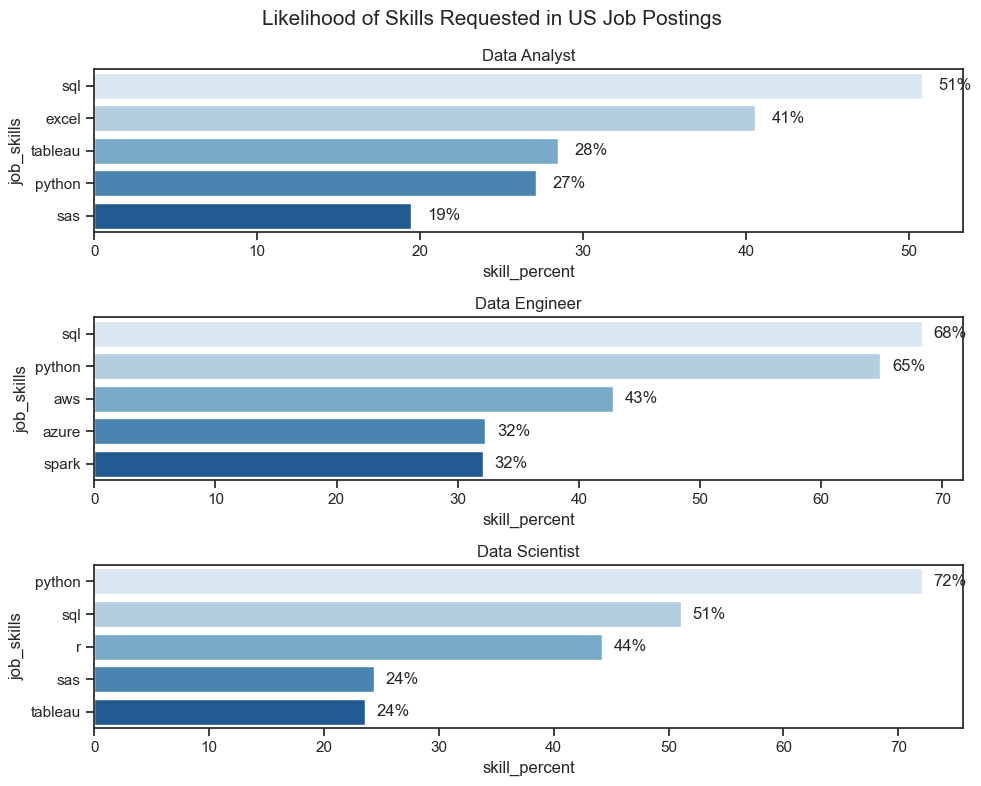

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='ticks')

fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 8))

if len(job_titles) == 1:
    ax = [ax]

for i, job_title in enumerate(job_titles):
    
    df_plot = df_skills_perc[
        df_skills_perc['job_title_short'].str.lower() == job_title.lower()
    ]

    print(f"{job_title} rows:", len(df_plot))  

    if df_plot.empty:
        ax[i].set_title(f"{job_title} (No Data)")
        continue

    df_plot = df_plot.head(5)[::-1]

    sns.barplot(
        data=df_plot,
        x='skill_percent',
        y='job_skills',
        ax=ax[i],
        palette='Blues_r'
    )

    ax[i].set_title(job_title)
    ax[i].invert_yaxis()

   
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)

plt.tight_layout(h_pad=1)
plt.show()